Python script that loads real fMRI data from OpenNeuro and extracts signals from DMN regions.

That would be the first step toward your research idea.

It would look like:

download subject
extract DMN time series
compute connectivity

Loading development fMRI dataset...
[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri
[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri/development_fmri
[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri/development_fmri

Dataset loaded.
Functional file: /home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
Confounds file: /home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_desc-reducedConfounds_regressors.tsv
TR (seconds): 2

Loading MSDL atlas...
[fetch_atlas_msdl] Dataset found in /home/john-walkey/nilearn_data/msdl_atlas
Atlas maps file: /home/john-walkey/nilearn_data/msdl_atlas/MSDL_rois/msdl_rois.nii
Number of atlas regions: 39

Atlas regions and network names:
 0 | L Aud | Aud
 1 | R Aud | Aud
 2 | Striate | Striate
 3 | L DMN | DMN
 4 | Med

/tmp/ipykernel_7620/3017724552.py:92: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  ts_all = masker.fit_transform(dev.func[0], confounds=dev.confounds[0])
/tmp/ipykernel_7620/3017724552.py:108: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  dmn_conn = corr_measure.fit_transform([ts_dmn])[0]


ts_all shape: (168, 39)
ts_dmn shape: (168, 4)

Computing connectivity matrix...
Connectivity matrix shape: (4, 4)

Rounded DMN connectivity matrix:
[[1.   0.74 0.34 0.71]
 [0.74 1.   0.26 0.73]
 [0.34 0.26 1.   0.35]
 [0.71 0.73 0.35 1.  ]]

Saved: dmn_connectivity_matrix.png


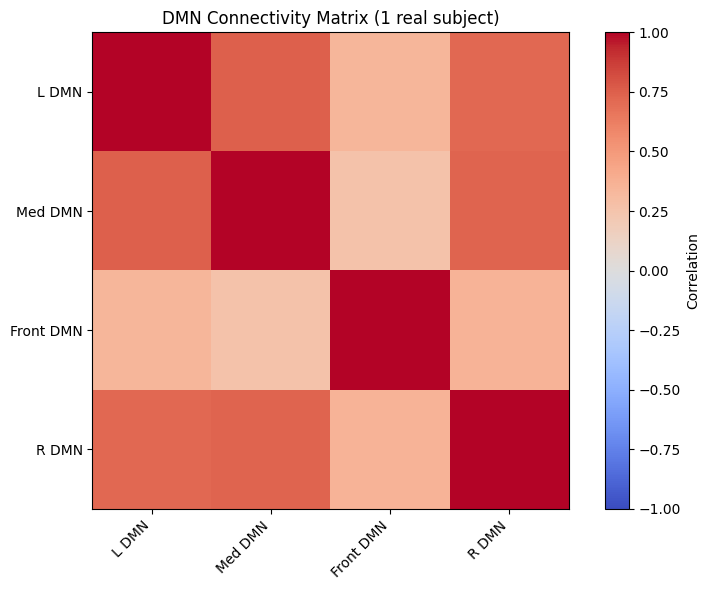


Creating mean fMRI image...
Saved: mean_fmri_image.png


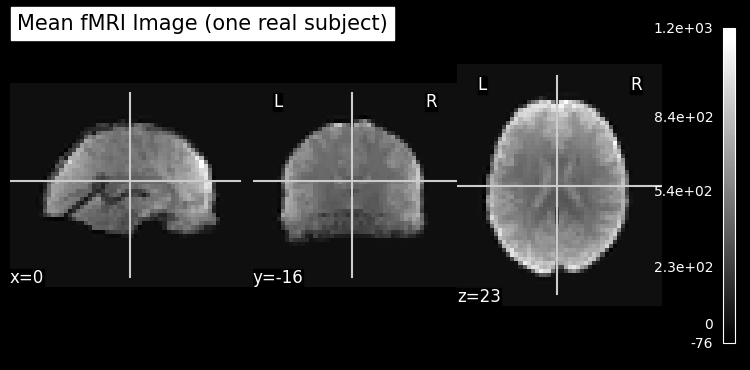


Done.


In [2]:
# openneuro_dmn_demo_clean.py
# ------------------------------------------------------------
# Beginner-friendly real fMRI demo using Nilearn
#
# What this does:
# 1. Downloads one real subject from Nilearn's development fMRI dataset
# 2. Loads the MSDL atlas
# 3. Finds likely DMN regions from atlas network names
# 4. Extracts ROI time series from the subject's 4D fMRI image
# 5. Computes a DMN connectivity matrix
# 6. Displays the matrix
# 7. Displays the mean fMRI image (3D average over time)
#
# Notes:
# - First run may take a while because data must download
# - Later runs are faster because Nilearn caches the files locally
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from nilearn import datasets, plotting
from nilearn.maskers import NiftiMapsMasker
from nilearn.connectome import ConnectivityMeasure
from nilearn.image import mean_img

# ------------------------------------------------------------
# STEP 1: Download one real fMRI subject
# ------------------------------------------------------------
print("Loading development fMRI dataset...")
dev = datasets.fetch_development_fmri(n_subjects=1)

print("\nDataset loaded.")
print("Functional file:", dev.func[0])
print("Confounds file:", dev.confounds[0])
print("TR (seconds):", dev.t_r)

# ------------------------------------------------------------
# STEP 2: Load the MSDL atlas
# ------------------------------------------------------------
print("\nLoading MSDL atlas...")
atlas = datasets.fetch_atlas_msdl()

print("Atlas maps file:", atlas.maps)
print("Number of atlas regions:", len(atlas.labels))

# ------------------------------------------------------------
# STEP 3: Inspect atlas labels and network names
# ------------------------------------------------------------
print("\nAtlas regions and network names:")
for i, (label, net) in enumerate(zip(atlas.labels, atlas.networks)):
    print(f"{i:2d} | {label} | {net}")

# ------------------------------------------------------------
# STEP 4: Find DMN regions robustly
# ------------------------------------------------------------
# Some versions may use slightly different network names,
# so we search flexibly for 'default' or 'dmn'.
dmn_idx = [
    i for i, net in enumerate(atlas.networks)
    if ("default" in str(net).lower()) or ("dmn" in str(net).lower())
]

print("\nDMN indices found:", dmn_idx)
print("Number of DMN regions found:", len(dmn_idx))

if len(dmn_idx) == 0:
    raise ValueError(
        "No DMN regions were found in atlas.networks.\n"
        "Look at the printed atlas network names above and adjust the selection rule."
    )

dmn_labels = [atlas.labels[i] for i in dmn_idx]
print("DMN labels:", dmn_labels)

# ------------------------------------------------------------
# STEP 5: Extract ROI time series from the 4D fMRI image
# ------------------------------------------------------------
# NiftiMapsMasker is appropriate for probabilistic/overlapping maps like MSDL.
print("\nExtracting ROI time series...")

masker = NiftiMapsMasker(
    maps_img=atlas.maps,
    standardize="zscore_sample",
    detrend=True,
    high_pass=0.01,
    low_pass=0.1,
    t_r=dev.t_r,
)

# ts_all shape = (timepoints, number_of_regions)
ts_all = masker.fit_transform(dev.func[0], confounds=dev.confounds[0])

print("ts_all shape:", ts_all.shape)

# Keep only the DMN columns
ts_dmn = ts_all[:, dmn_idx]
print("ts_dmn shape:", ts_dmn.shape)

if ts_dmn.shape[1] == 0:
    raise ValueError("DMN time-series matrix has zero columns.")

# ------------------------------------------------------------
# STEP 6: Compute the DMN connectivity matrix
# ------------------------------------------------------------
print("\nComputing connectivity matrix...")
corr_measure = ConnectivityMeasure(kind="correlation")
dmn_conn = corr_measure.fit_transform([ts_dmn])[0]

print("Connectivity matrix shape:", dmn_conn.shape)
print("\nRounded DMN connectivity matrix:")
print(np.round(dmn_conn, 2))

# ------------------------------------------------------------
# STEP 7: Plot DMN connectivity matrix
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.imshow(dmn_conn, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="Correlation")
plt.xticks(range(len(dmn_labels)), dmn_labels, rotation=45, ha="right")
plt.yticks(range(len(dmn_labels)), dmn_labels)
plt.title("DMN Connectivity Matrix (1 real subject)")
plt.tight_layout()
plt.savefig("dmn_connectivity_matrix.png", dpi=200)
print("\nSaved: dmn_connectivity_matrix.png")
plt.show()

# ------------------------------------------------------------
# STEP 8: Show a real mean fMRI image
# ------------------------------------------------------------
# The functional file is 4D (x, y, z, time).
# mean_img converts it into a 3D average image for display.
print("\nCreating mean fMRI image...")
mean_func = mean_img(dev.func[0])

display = plotting.plot_epi(
    mean_func,
    title="Mean fMRI Image (one real subject)",
    display_mode="ortho",
    draw_cross=True,
    annotate=True,
)

display.savefig("mean_fmri_image.png")
print("Saved: mean_fmri_image.png")

plotting.show()

print("\nDone.")

## What this script is doing:
downloads one real subject
extracts a few valid network regions
computes connectivity
shows the matrix
shows a mean fMRI image

#### What to say to a PI - You could say:

“I used a real open fMRI dataset, extracted time series from DMN atlas regions, and computed a subject-level functional connectivity matrix. My next step is to relate these connectivity values to behavioral or psychological variables such as anxiety.”

That is a solid statement.

##### Two important cautions

This script is a learning demo, not a publishable anxiety analysis. For real work, you would want more subjects, careful confound handling, a justified atlas/ROI strategy, and subject-level symptom measures. Nilearn’s own docs present these dataset fetchers and connectome examples as convenient examples for realistic workflows, not as final analysis pipelines.

Also, Nilearn has a general fetch_openneuro_dataset function for downloading OpenNeuro BIDS datasets directly, but the script above is simpler for getting started fast.